# Random Forest — Predicting Turbidity from Catchment Features

Fits `eoflow.models.RandomForest` (a bagged-decision-tree wrapper) to a catchment-features
CSV produced by the pipeline in `docs/PIPELINE.md` (`scripts/prepare_samples.py` →
`scripts/extract_features.py`), and does a basic accuracy analysis of how well the
terrain / soil / rainfall / EO features predict the target determinand (Turbidity by
default).

This is the tree-ensemble counterpart to `linear_regression_turbidity.ipynb` and
`lasso_regression_turbidity.ipynb` — same hyperparameters as the `RandomForest` entry in
`model_comparison_turbidity.ipynb`, but with the full per-model breakdown (feature
importances, correlation matrix, glossary, leave-one-out CV) those two notebooks have and
the comparison notebook deliberately skips.

Unlike the linear models, RandomForest makes no linearity or feature-scale assumptions —
it splits on raw feature values, so there's no coefficient sign to read, only an unsigned
importance score per feature.

---

### Contents

1. Configuration — set `DATA_PATH`, `TARGET_COLUMN`, and forest hyperparameters here
2. Load & inspect data
3. Train / test split
4. Fit the model
5. Holdout accuracy
6. Predicted vs. actual, and residuals
7. Leave-one-out cross-validation (robust to the small-sample regime)
8. Feature importances
9. Summary
10. Feature correlation matrix
11. Feature glossary

---

> **Note on sample size:** the default `DATA_PATH` below points at the full
> `scripts/extract_features.py` output for `data/sample_instances`. Rainfall/NDVI/NDWI
> coverage is sparse (most EA samples predate the NIMROD/Sentinel-2 data on disk), so
> after dropping incomplete rows the effective training set is much smaller than the
> raw row count — see section 2's missing-feature counts.

## 1 — Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, train_test_split

from eoflow.models.base import split_features_target
from eoflow.models.RandomForest import RandomForest

In [2]:
# ── User-editable settings ───────────────────────────────────────────────────────────────

# Path to the features CSV written by scripts/extract_features.py
DATA_PATH = Path(
    "/home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_full.csv"
)

# Column to predict. `result` holds the measured determinand value for every row
# (its `unit` column records which determinand) — for a CSV that has already been
# filtered to Turbidity samples, this *is* Turbidity.
TARGET_COLUMN = "result"

# Train/test split
TEST_SIZE = 0.2
RANDOM_STATE = 0

# Model hyperparameters (see eoflow.models.RandomForest) — matches the RandomForest
# entry in model_comparison_turbidity.ipynb
N_ESTIMATORS = 300
MAX_DEPTH = None

# ──────────────────────────────────────────────────────────────────────

assert DATA_PATH.exists(), f"CSV not found: {DATA_PATH}"

ACCENT = "#3B6FE0"      # primary series (train / fitted values)
ACCENT_MUTED = "#98A6C2"  # secondary series (test / holdout)
IMPORTANCE_HUE = "#C4903D"  # feature-importance bars (unsigned, so a single hue)
GRID = "#E4E7ED"

print("Data path     :", DATA_PATH)
print("Target column :", TARGET_COLUMN)
print("n_estimators  :", N_ESTIMATORS)
print("max_depth     :", MAX_DEPTH)

Data path     : /home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_full.csv
Target column : result
n_estimators  : 300
max_depth     : None


## 2 — Load & inspect data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 437 rows × 54 columns


,notation,site_name,date,result,unit,flow_acc_at_pour_point_log,catchment_area_km2,catchment_perimeter_km,catchment_compactness,elevation_mean_m,...,rainfall_max_mm_h,rainfall_total_depth_mm,rainfall_spatial_cv,interaction_bare_x_steep10,interaction_bare_x_steep15,interaction_erodible_x_bare,interaction_wet_x_steep10,interaction_rain_x_bare,interaction_spr_x_bare,interaction_slope_mean_x_inv_ndvi
0,SW-70220104,RIVER AXE AT AXE BRIDGE BELOW COLYTON & COLYFO...,2022-04-06,3.6,NEPHELOMETRIC TURBIDITY UNITS,12.235981,124.311999,81.546100,0.234918,114.887733,...,26.0,4.913725,4.117858,0.000436,0.000077,0.000701,0.000001,0.000168,0.165021,1.906083
1,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2010-01-05,3.6,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2010-09-28,3.0,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2011-06-06,2.5,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2012-02-15,3.6,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
assert TARGET_COLUMN in df.columns, f"{TARGET_COLUMN!r} not in columns: {list(df.columns)}"

if "unit" in df.columns:
    print("Determinand unit(s) present:")
    print(df["unit"].value_counts())

print(f"\n{TARGET_COLUMN} summary:")
df[TARGET_COLUMN].describe()

Determinand unit(s) present:
unit
NEPHELOMETRIC TURBIDITY UNITS    437
Name: count, dtype: int64

result summary:


count     396.000000
mean       41.793333
std       499.312932
min         1.000000
25%         2.500000
50%         5.000000
75%        13.275000
max      9920.000000
Name: result, dtype: float64

In [5]:
# Split into predictors X and target y. This drops the identity columns
# (notation, site_name, date, result, unit) and keeps every other numeric column.
X, y = split_features_target(df, target_column=TARGET_COLUMN)

n_missing = X.isna().any(axis=1).sum()
print(f"Features: {X.shape[1]} columns")
print(f"Rows with at least one missing feature: {n_missing}/{len(X)}")
print(f"Rows with missing target: {y.isna().sum()}/{len(y)}")

Features: 49 columns
Rows with at least one missing feature: 381/437
Rows with missing target: 41/437


In [6]:
# Drop rows with a missing target or any missing feature. `model.fit` would silently
# drop NaN rows on its own, but `model.score`/`model.predict` do not — leaving NaNs in
# X_test would otherwise poison the holdout R² / RMSE / MAE with NaN. Cleaning once,
# upfront, keeps train/test/LOO all operating on the same complete-row subset. Tree
# ensembles also can't handle NaN natively, unlike some gradient-boosting libraries.
complete_mask = X.notna().all(axis=1) & y.notna()
n_dropped = int((~complete_mask).sum())
print(f"Dropping {n_dropped}/{len(X)} rows with missing target or feature values.")

X, y = X.loc[complete_mask].reset_index(drop=True), y.loc[complete_mask].reset_index(drop=True)
print(f"Remaining: {len(X)} rows")

Dropping 384/437 rows with missing target or feature values.
Remaining: 53 rows


## 3 — Train / test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")

if len(X_test) < 3:
    print(
        "\nWarning: very few holdout rows — the train/test split metrics below will be "
        "noisy. See section 7 for a leave-one-out estimate that uses every row."
    )

Train: 42 rows   Test: 11 rows


In [8]:
X_train.head()

,flow_acc_at_pour_point_log,catchment_area_km2,catchment_perimeter_km,catchment_compactness,elevation_mean_m,elevation_range_m,elevation_std_m,slope_mean_deg,slope_std_deg,slope_p90_deg,...,rainfall_max_mm_h,rainfall_total_depth_mm,rainfall_spatial_cv,interaction_bare_x_steep10,interaction_bare_x_steep15,interaction_erodible_x_bare,interaction_wet_x_steep10,interaction_rain_x_bare,interaction_spr_x_bare,interaction_slope_mean_x_inv_ndvi
10,10.038892,13.863431,30.773517,0.183961,247.875799,321.544659,63.905662,6.925219,4.957789,13.382841,...,8.90625,9.307168,2.742180,0.138398,0.045866,0.521636,0.000084,0.117611,3.839685,5.595110
27,8.631414,3.375047,14.200226,0.210329,110.101635,116.914410,29.295383,4.014873,2.185194,7.061845,...,38.93750,18.016276,4.525829,0.001524,0.000000,0.000000,0.000000,0.037739,6.475390,2.957293
52,7.370231,0.955418,5.607783,0.381787,192.528435,65.043564,14.963759,3.380606,1.427776,5.213104,...,12.15625,39.505208,3.704946,0.000000,0.000000,0.000000,0.000000,0.145751,25.687186,2.926339
30,10.189080,16.054549,30.056713,0.223319,131.829377,118.092171,23.858764,3.059112,1.672691,5.243051,...,23.21875,36.492350,2.433100,0.000017,0.000000,0.000000,0.000008,0.001766,0.251986,1.265091
37,11.773650,77.735123,53.027935,0.347390,205.167291,321.612370,56.124760,6.803299,4.758421,13.461116,...,48.31250,25.830122,3.000431,0.000503,0.000201,0.000000,0.000021,0.000435,0.077597,2.933008


## 4 — Fit the model

In [9]:
model = RandomForest(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

print(f"Fitted on {len(X_train)} rows × {len(model.feature_names_)} features")
print(f"Trees: {N_ESTIMATORS}   Max depth: {MAX_DEPTH}")

2026-07-23 13:03:45,593 - eoflow.models.RandomForest - INFO - Fit RandomForest on 42 rows × 49 features.


Fitted on 42 rows × 49 features
Trees: 300   Max depth: None


## 5 — Holdout accuracy

In [10]:
train_metrics = model.score(X_train, y_train)
test_metrics = model.score(X_test, y_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])
metrics_df

,r2,rmse,mae
train,0.851513,7.012003,3.659992
test,0.608515,9.600029,7.703758


## 6 — Predicted vs. actual, and residuals

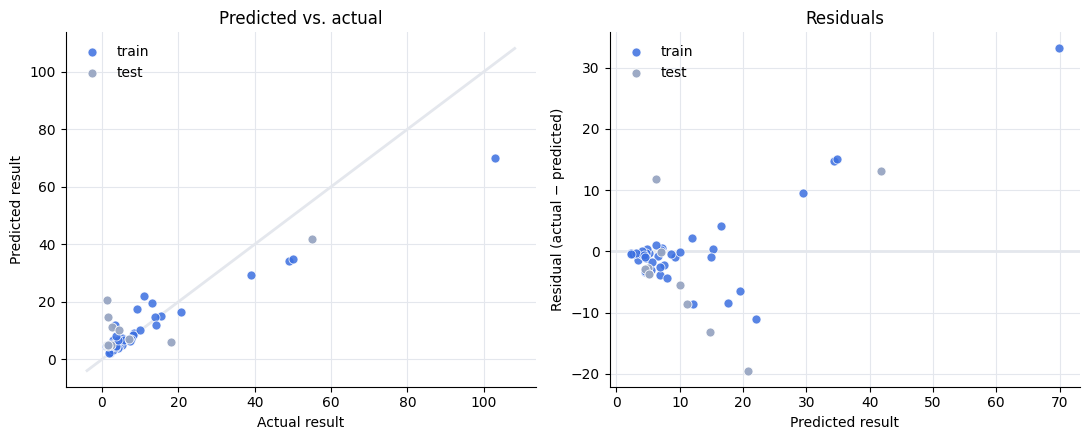

In [11]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# — Predicted vs. actual —
ax = axes[0]
all_vals = np.concatenate([y_train, y_test, y_train_pred, y_test_pred])
lo, hi = float(np.min(all_vals)), float(np.max(all_vals))
pad = 0.05 * (hi - lo if hi > lo else 1.0)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=GRID, lw=2, zorder=1, label="_nolegend_")
ax.scatter(y_train, y_train_pred, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test, y_test_pred, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Actual {TARGET_COLUMN}")
ax.set_ylabel(f"Predicted {TARGET_COLUMN}")
ax.set_title("Predicted vs. actual")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

# — Residuals —
ax = axes[1]
resid_train = np.asarray(y_train) - y_train_pred
resid_test = np.asarray(y_test) - y_test_pred
ax.axhline(0, color=GRID, lw=2, zorder=1)
ax.scatter(y_train_pred, resid_train, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test_pred, resid_test, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Predicted {TARGET_COLUMN}")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

## 7 — Leave-one-out cross-validation

A single train/test split is unstable on small datasets — which row ends up in the
holdout set can swing the metrics a lot. Leave-one-out (LOO) refits the model once
per row, holding that row out, and pools every out-of-sample prediction into one set
of accuracy metrics. It's more expensive but uses every row as a test point exactly
once, giving a steadier estimate — especially useful while the sample dataset is
this small. Refitting a 300-tree forest per fold is the slowest step in this notebook,
but still fast at this row count.

In [12]:
loo = LeaveOneOut()
y_true_loo, y_pred_loo = [], []

for train_idx, holdout_idx in loo.split(X):
    fold_model = RandomForest(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
    fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_loo.append(fold_model.predict(X.iloc[holdout_idx])[0])
    y_true_loo.append(y.iloc[holdout_idx].to_numpy()[0])

y_true_loo = np.asarray(y_true_loo, dtype=float)
y_pred_loo = np.asarray(y_pred_loo, dtype=float)
resid_loo = y_true_loo - y_pred_loo

ss_res = float(np.sum(resid_loo**2))
ss_tot = float(np.sum((y_true_loo - y_true_loo.mean()) ** 2))
loo_metrics = {
    "r2": 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan"),
    "rmse": float(np.sqrt(np.mean(resid_loo**2))),
    "mae": float(np.mean(np.abs(resid_loo))),
}

metrics_df.loc["loo"] = loo_metrics
metrics_df

2026-07-23 13:03:46,244 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:03:46,581 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:03:46,881 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:03:47,293 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:03:47,652 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


...

2026-07-23 13:04:02,650 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:04:03,013 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:04:03,388 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


2026-07-23 13:04:03,768 - eoflow.models.RandomForest - INFO - Fit RandomForest on 52 rows × 49 features.


,r2,rmse,mae
train,0.851513,7.012003,3.659992
test,0.608515,9.600029,7.703758
loo,-0.002554,17.692337,9.044937


## 8 — Feature importances

Impurity-based importances from the model fitted on the full training split (section 4),
largest `TOP_N_FEATURES` by value. Unlike the linear-model coefficients in the OLS/Lasso
notebooks, these are unsigned and sum to 1 across all features — there's no direction to
read, only relative importance. They're also biased toward high-cardinality / continuous
features (e.g. `catchment_area_km2`) over low-cardinality ones (e.g. soil fractions near
0), a known quirk of impurity-based importance.

Showing the 20 largest importances of 49.


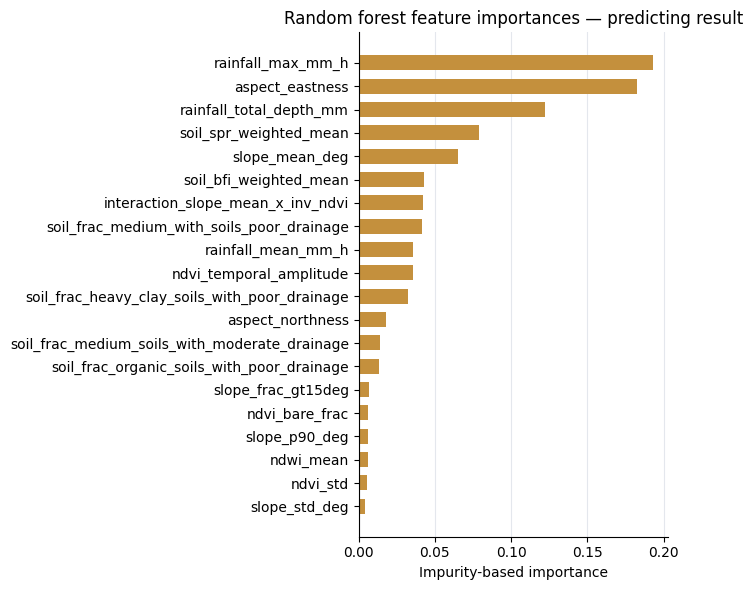

In [13]:
TOP_N_FEATURES = 20

top_features = model.feature_importances.sort_values()
if len(top_features) > TOP_N_FEATURES:
    top_features = top_features.iloc[-TOP_N_FEATURES:]
    print(f"Showing the {TOP_N_FEATURES} largest importances of {len(model.feature_importances)}.")

fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(top_features))))
ax.barh(top_features.index, top_features.to_numpy(), color=IMPORTANCE_HUE, height=0.65)
ax.set_xlabel("Impurity-based importance")
ax.set_title(f"Random forest feature importances — predicting {TARGET_COLUMN}")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 9 — Summary

In [14]:
print(f"Dataset      : {DATA_PATH.name}  ({len(df)} rows)")
print(f"Target       : {TARGET_COLUMN}")
print(f"Features     : {len(model.feature_names_)}")
print(f"Forest       : {N_ESTIMATORS} trees, max_depth={MAX_DEPTH}")
print()
print("Accuracy (R² / RMSE / MAE):")
print(metrics_df.round(4).to_string())
print()
print(
    "Note: with a handful of rows these metrics are illustrative only — re-run against "
    "a larger extract_features.py output for a meaningful accuracy read."
)

Dataset      : catchment_features_full.csv  (437 rows)
Target       : result
Features     : 49
Forest       : 300 trees, max_depth=None

Accuracy (R² / RMSE / MAE):
           r2     rmse     mae
train  0.8515   7.0120  3.6600
test   0.6085   9.6000  7.7038
loo   -0.0026  17.6923  9.0449

Note: with a handful of rows these metrics are illustrative only — re-run against a larger extract_features.py output for a meaningful accuracy read.


## 10 — Feature correlation matrix

Pearson correlation between the section 8 top-importance features and each other, plus
each feature's correlation with the target (highlighted). Two features with `|r|` close
to 1 are carrying similar information — useful context here since RandomForest, unlike
Lasso, doesn't zero out either one of a correlated pair, so both can show up with
substantial importance despite being largely redundant.

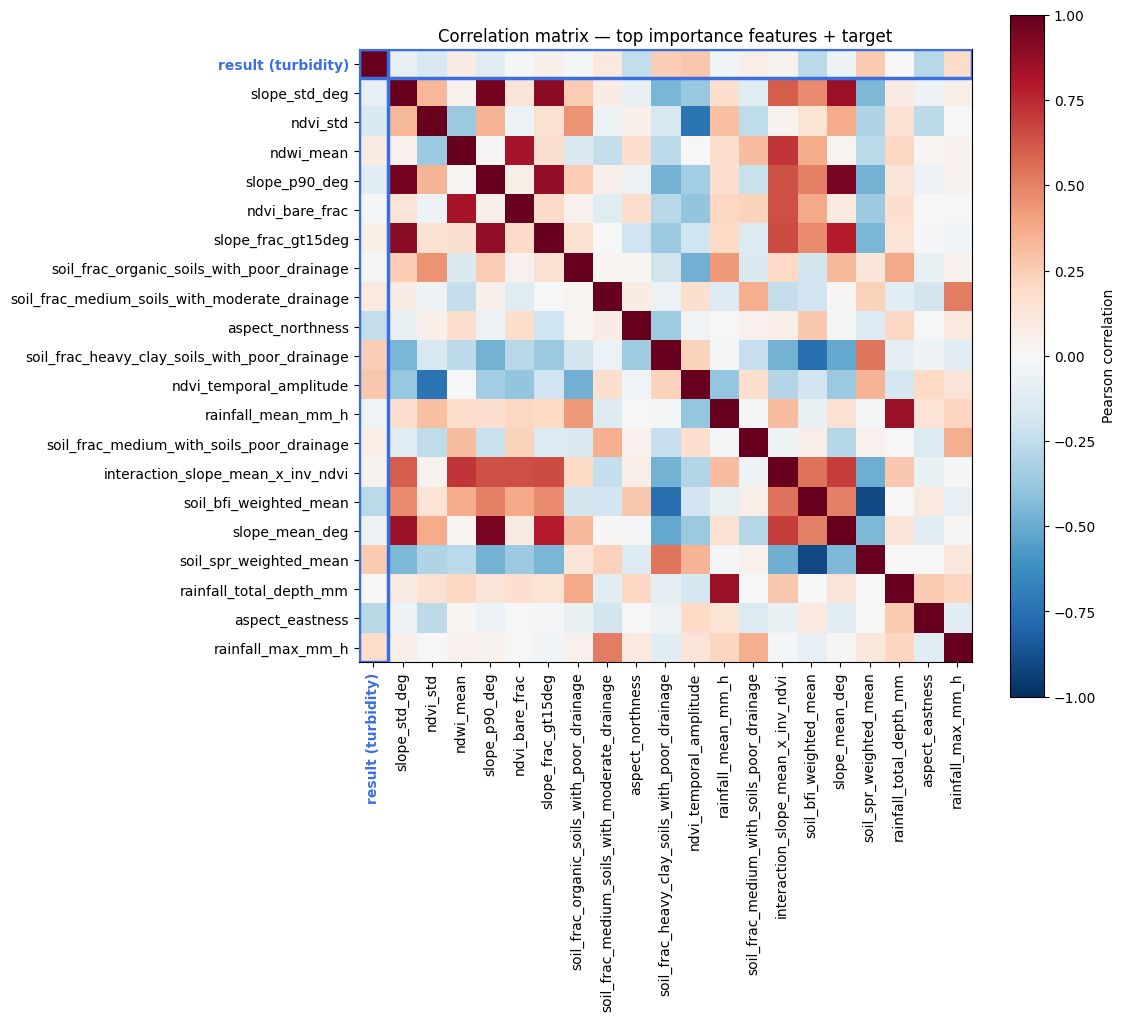

In [15]:
target_label = f"{TARGET_COLUMN} (turbidity)"
corr_features = top_features.index.tolist()
corr_df = pd.concat([y.rename(target_label), X[corr_features]], axis=1).corr()

fig, ax = plt.subplots(figsize=(0.45 * len(corr_df) + 2, 0.45 * len(corr_df) + 2))
im = ax.imshow(corr_df.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_df)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index)

# Highlight the target's row and column
target_pos = corr_df.columns.get_loc(target_label)
for patch in (
    plt.Rectangle((-0.5, target_pos - 0.5), len(corr_df), 1, fill=False, edgecolor=ACCENT, lw=2.5, zorder=5),
    plt.Rectangle((target_pos - 0.5, -0.5), 1, len(corr_df), fill=False, edgecolor=ACCENT, lw=2.5, zorder=5),
):
    ax.add_patch(patch)
ax.get_xticklabels()[target_pos].set_color(ACCENT)
ax.get_xticklabels()[target_pos].set_fontweight("bold")
ax.get_yticklabels()[target_pos].set_color(ACCENT)
ax.get_yticklabels()[target_pos].set_fontweight("bold")

fig.colorbar(im, ax=ax, label="Pearson correlation", shrink=0.8)
ax.set_title("Correlation matrix — top importance features + target")
fig.tight_layout()
plt.show()

## 11 — Feature glossary

What each of the section 8 top-importance features actually measures. Descriptions come
from `eoflow.feature_glossary.FEATURE_DESCRIPTIONS`, keyed by feature name, so this table
always reflects the features `model` actually ranked highest above — not a fixed list.

> Rainfall, NDVI, and NDWI features come from the sparsest layers in the current dataset (see the
> "Rows with at least one missing feature" count in section 2) — most EA turbidity samples predate
> the NIMROD/Sentinel-2 coverage on disk, so these importances are fit on a small complete-row
> subset and should be read as directional/illustrative rather than precise.

In [16]:
from eoflow.feature_glossary import describe_features

# top_features is ordered ascending by importance (see section 8); reverse so the
# largest-importance feature is listed first.
feature_table = describe_features(top_features.index[::-1])
feature_table

,feature,group,description
0,rainfall_max_mm_h,Rainfall,Peak NIMROD radar rainfall rate (mm/h) over th...
1,aspect_eastness,Terrain,Mean sin(aspect) across the catchment — +1 = d...
2,rainfall_total_depth_mm,Rainfall,Total rainfall depth (mm) accumulated over the...
3,soil_spr_weighted_mean,Soil,Area-weighted mean Standard Percentage Runoff ...
4,slope_mean_deg,Terrain,"Mean terrain slope across the catchment, in de..."
5,soil_bfi_weighted_mean,Soil,Area-weighted mean Baseflow Index — higher val...
6,interaction_slope_mean_x_inv_ndvi,Interaction,slope_mean_deg × (1 − ndvi_mean) — mean steepn...
7,soil_frac_medium_with_soils_poor_drainage,Soil,"Fractional coverage of the SEARG ""Medium with ..."
8,rainfall_mean_mm_h,Rainfall,Mean NIMROD radar rainfall rate (mm/h) over th...
9,ndvi_temporal_amplitude,NDVI,Mean per-pixel (max − min) NDVI over the obser...
